# Capstone Project 2
Semiconductor Manufacturing Process Analysis and Pass/Fail Prediction

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

print("Libraries imported successfully!")

Libraries imported successfully!


In [27]:
# Load the dataset

data = pd.read_csv("signal-data.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", data.shape)

Dataset loaded successfully!
Shape of dataset: (1567, 592)


In [28]:
# Display first 5 rows

print("First 5 Rows:")
print(data.head())

print("\nDataset Information:")
print(data.info())

print("\nStatistical Summary:")
print(data.describe())

First 5 Rows:
                  Time        0        1          2          3       4      5  \
0  2008-07-19 11:55:00  3030.93  2564.00  2187.7333  1411.1265  1.3602  100.0   
1  2008-07-19 12:32:00  3095.78  2465.14  2230.4222  1463.6606  0.8294  100.0   
2  2008-07-19 13:17:00  2932.61  2559.94  2186.4111  1698.0172  1.5102  100.0   
3  2008-07-19 14:43:00  2988.72  2479.90  2199.0333   909.7926  1.3204  100.0   
4  2008-07-19 15:22:00  3032.24  2502.87  2233.3667  1326.5200  1.5334  100.0   

          6       7       8  ...       581     582     583     584      585  \
0   97.6133  0.1242  1.5005  ...       NaN  0.5005  0.0118  0.0035   2.3630   
1  102.3433  0.1247  1.4966  ...  208.2045  0.5019  0.0223  0.0055   4.4447   
2   95.4878  0.1241  1.4436  ...   82.8602  0.4958  0.0157  0.0039   3.1745   
3  104.2367  0.1217  1.4882  ...   73.8432  0.4990  0.0103  0.0025   2.0544   
4  100.3967  0.1235  1.5031  ...       NaN  0.4800  0.4766  0.1045  99.3032   

      586     587     58

In [29]:
# Check missing values

print("Missing values in each column:")
print(data.isnull().sum())

print("\nTotal missing values:")
print(data.isnull().sum().sum())

Missing values in each column:
Time          0
0             6
1             7
2            14
3            14
             ..
586           1
587           1
588           1
589           1
Pass/Fail     0
Length: 592, dtype: int64

Total missing values:
41951


In [30]:
# Percentage of missing values

missing_percent = (data.isnull().sum() / len(data)) * 100

print("Missing Value Percentage:")
print(missing_percent[missing_percent > 0])

Missing Value Percentage:
0      0.382897
1      0.446713
2      0.893427
3      0.893427
4      0.893427
         ...   
585    0.063816
586    0.063816
587    0.063816
588    0.063816
589    0.063816
Length: 538, dtype: float64


In [31]:
# Fill missing values using the column mean

data = data.fillna(data.mean(numeric_only=True))

print("Missing values after filling:")
print(data.isnull().sum().sum())

Missing values after filling:
0


In [32]:
# Separate features and target

X = data.drop("Pass/Fail", axis=1)
y = data["Pass/Fail"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1567, 591)
Target Shape: (1567,)


In [33]:
# Check target class distribution

print(y.value_counts())

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


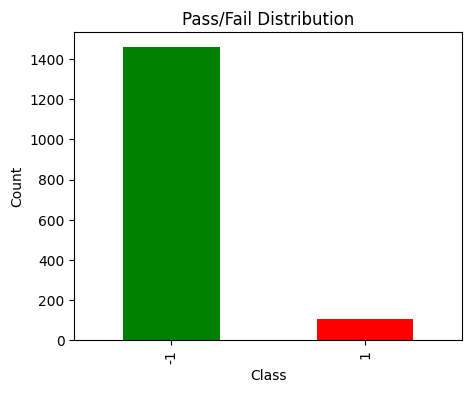

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
y.value_counts().plot(kind='bar', color=['green', 'red'])

plt.title("Pass/Fail Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

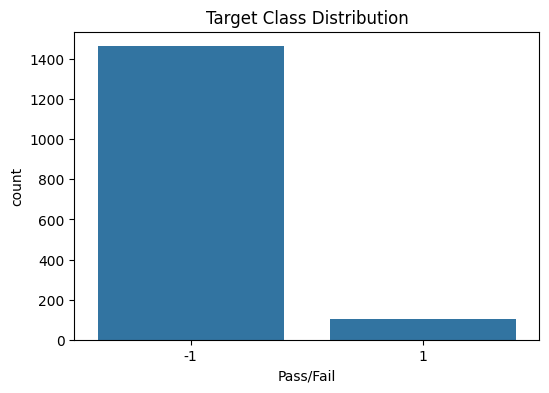

In [35]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=y)

plt.title("Target Class Distribution")
plt.show()

In [36]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (1253, 591)
Testing Features: (314, 591)
Training Labels: (1253,)
Testing Labels: (314,)


In [37]:
X.select_dtypes(include=['object']).columns

Index(['Time'], dtype='object')

In [38]:
# Remove the Time column
X = X.drop(columns=['Time'])

print("Time column removed successfully!")
print(X.shape)

Time column removed successfully!
(1567, 590)


In [39]:
# Remove Time column from X
X = X.drop(columns=['Time'], errors='ignore')

# Split the data again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1253, 590)
(314, 590)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data standardized successfully!")

Data standardized successfully!


In [41]:
print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (1253, 590)
Testing Data Shape: (314, 590)


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9235668789808917

Classification Report:
              precision    recall  f1-score   support

          -1       0.92      1.00      0.96       290
           1       0.00      0.00      0.00        24

    accuracy                           0.92       314
   macro avg       0.46      0.50      0.48       314
weighted avg       0.85      0.92      0.89       314



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train SVM model
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm.predict(X_test_scaled)

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9235668789808917

Classification Report:
              precision    recall  f1-score   support

          -1       0.92      1.00      0.96       290
           1       0.00      0.00      0.00        24

    accuracy                           0.92       314
   macro avg       0.46      0.50      0.48       314
weighted avg       0.85      0.92      0.89       314



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# Predict
y_pred_nb = nb.predict(X_test_scaled)

# Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.21656050955414013

Classification Report:
              precision    recall  f1-score   support

          -1       0.94      0.16      0.28       290
           1       0.08      0.88      0.15        24

    accuracy                           0.22       314
   macro avg       0.51      0.52      0.21       314
weighted avg       0.87      0.22      0.27       314



In [45]:
import joblib

joblib.dump(rf, "best_random_forest_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [46]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ]
})

print(results)

           Model  Accuracy
0  Random Forest  0.923567
1            SVM  0.923567
2    Naive Bayes  0.216561


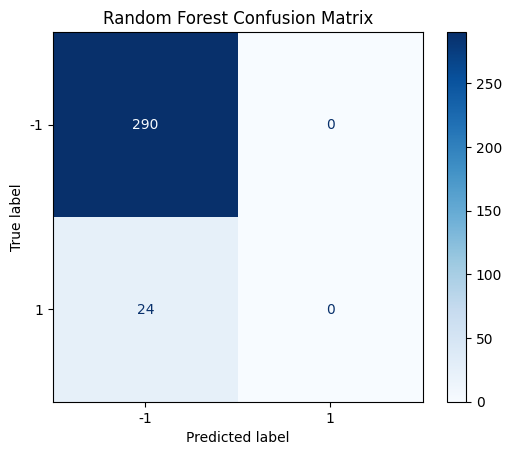

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test_scaled, y_test, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

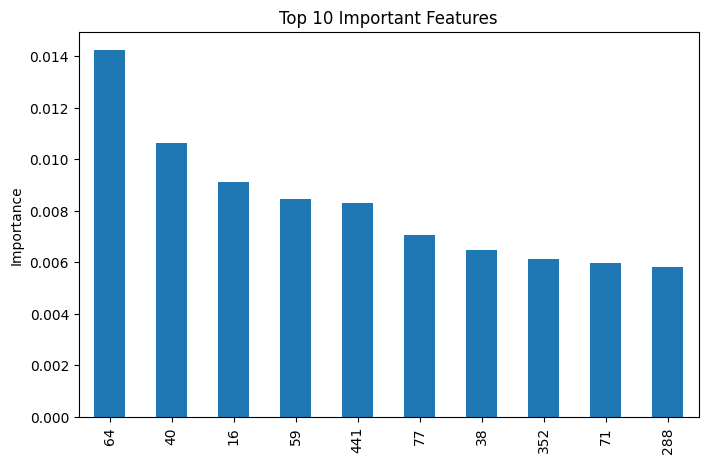

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top10.plot(kind='bar')
plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()

This project analyzed the semiconductor manufacturing dataset and built machine learning models to predict Pass/Fail outcomes. The dataset was cleaned by handling missing values, removing non-numeric columns, and standardizing the features. Three supervised learning models—Random Forest, SVM, and Naive Bayes—were trained and evaluated. Among them, the Random Forest model achieved the highest accuracy of approximately 92.36%, making it the best-performing model for this dataset. The results show that proper preprocessing and model selection significantly improve prediction performance. This model can help identify potential failures in semiconductor manufacturing and support quality control.